# Arabic Fake News Detection in Egypt Using NLP

This project aims to detect fake news written in Egyptian Arabic using Natural Language Processing techniques. Multiple machine learning and deep learning models were developed and compared using labeled and external Egyptian Arabic corpora.

# 1. Import Libraries

In [20]:
import pandas as pd
import numpy as np
import torch
import numpy as np
from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer
)
from sklearn.metrics import accuracy_score, precision_recall_fscore_support

# 2. Load Main Labeled Dataset

In [2]:
file_path = "/kaggle/input/datasets/mahmoudelgendy68/egypt-fake-tweets-detection-dataset-labeled/Egypt_Fake_Tweets_Labeled.xlsx"   # change path if needed

df = pd.read_excel(file_path)


In [3]:
print("Dataset Shape:", df.shape)
print("\nColumn Names:")
print(df.columns)

print("\nFirst 5 Rows:")
display(df.head())


Dataset Shape: (22906, 3)

Column Names:
Index(['Text', 'Label', 'TextLength'], dtype='object')

First 5 Rows:


,Text,Label,TextLength
0,بقالي كتير اوي مكلتش شاورما حلوة كده .,idk,38
1,اكبر خطا ترتكبه ان تعامل الناس باخلاقك انت مش ...,r,61
2,دائما اكره اخر ليله في كل مكان .,idk,34
3,يارب اللى يسرق تويتاتى يدخل النار .,idk,35
4,الاسراف فى تناول القهوة يسبب الوفاه .,r,37


In [4]:
print("\nMissing Values:")
print(df.isnull().sum())



Missing Values:
Text          0
Label         0
TextLength    0
dtype: int64


In [8]:
# remove spaces from column names
df.columns = df.columns.str.strip()

# make lowercase
df.columns = df.columns.str.lower()

print(df.columns.tolist())

['text', 'label', 'textlength']


In [9]:
print(df["label"].value_counts())

label
idk    16003
r       5286
f       1617
Name: count, dtype: int64


In [6]:
print("\nData Types:")
print(df.dtypes)


Data Types:
Text          object
Label         object
TextLength     int64
dtype: object


# 3. Dataset Cleaning and Label Preparation

The original dataset contained three labels:
- r = Real
- f = Fake
- idk = Uncertain

To ensure supervised learning quality, uncertain samples were removed.

In [11]:

df = df[df["label"].isin(["r", "f"])].copy()

# Rename labels
df["label"] = df["label"].map({
    "r": "Real",
    "f": "Fake"
})

# Reset index
df.reset_index(drop=True, inplace=True)

print("Dataset Shape:", df.shape)
print(df["label"].value_counts())

df.head()

Dataset Shape: (6903, 3)
label
Real    5286
Fake    1617
Name: count, dtype: int64


,text,label,textlength
0,اكبر خطا ترتكبه ان تعامل الناس باخلاقك انت مش ...,Real,61
1,الاسراف فى تناول القهوة يسبب الوفاه .,Real,37
2,جروب الدفعه ليلة الامتحان دايما بتحس ان الناس ...,Real,101
3,النقاش هو الذى يؤدي الى نتيجه اما التعصب فيولد...,Real,63
4,وصلت الى مرحلة اني كرهت بلدى وانى فيها .,Fake,42


# 4. Arabic Text Preprocessing

In [12]:
import re
import string

# Arabic stopwords basic list
arabic_stopwords = set([
    'في','من','على','الى','إلى','عن','ما','ماذا','هذا','هذه','ذلك','تلك',
    'هو','هي','هم','هن','انا','أنت','انت','أنتم','نحن','كان','كانت',
    'يكون','يمكن','مع','او','أو','ثم','بل','لكن','لأن','اذا','إذا',
    'كل','بعض','قد','لقد','تم','هل','لا','نعم','إن','أن','اي','أي'
])

def clean_arabic(text):
    text = str(text)
    
    # remove urls
    text = re.sub(r'http\S+|www\S+', '', text)
    
    # remove mentions
    text = re.sub(r'@\w+', '', text)
    
    # remove hashtags symbol only
    text = text.replace("#", "")
    
    # remove numbers
    text = re.sub(r'\d+', '', text)
    
    # normalize Arabic letters
    text = re.sub("[إأآا]", "ا", text)
    text = re.sub("ى", "ي", text)
    text = re.sub("ؤ", "و", text)
    text = re.sub("ئ", "ي", text)
    text = re.sub("ة", "ه", text)
    
    # remove tashkeel
    text = re.sub(r'[\u0617-\u061A\u064B-\u0652]', '', text)
    
    # remove punctuation
    text = re.sub(r'[^\w\s]', ' ', text)
    
    # remove extra spaces
    text = re.sub(r'\s+', ' ', text).strip()
    
    # remove stopwords
    words = text.split()
    words = [w for w in words if w not in arabic_stopwords]
    
    return " ".join(words)

# Apply cleaning
df["clean_text"] = df["text"].apply(clean_arabic)

# Show sample
df[["text", "clean_text"]].head()

,text,clean_text
0,اكبر خطا ترتكبه ان تعامل الناس باخلاقك انت مش ...,اكبر خطا ترتكبه ان تعامل الناس باخلاقك مش باخل...
1,الاسراف فى تناول القهوة يسبب الوفاه .,الاسراف تناول القهوه يسبب الوفاه
2,جروب الدفعه ليلة الامتحان دايما بتحس ان الناس ...,جروب الدفعه ليله الامتحان دايما بتحس ان الناس ...
3,النقاش هو الذى يؤدي الى نتيجه اما التعصب فيولد...,النقاش الذي يودي الي نتيجه اما التعصب فيولد تع...
4,وصلت الى مرحلة اني كرهت بلدى وانى فيها .,وصلت الي مرحله اني كرهت بلدي واني فيها


# 5. Exploratory Data Analysis

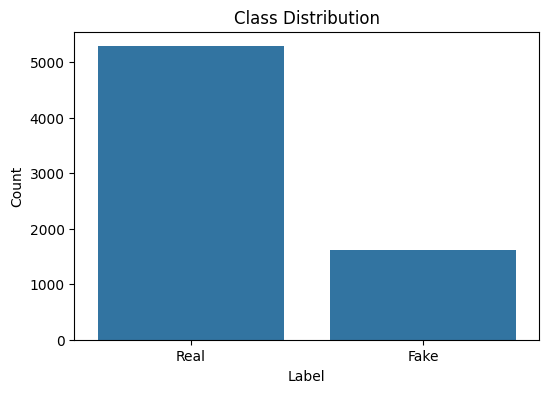

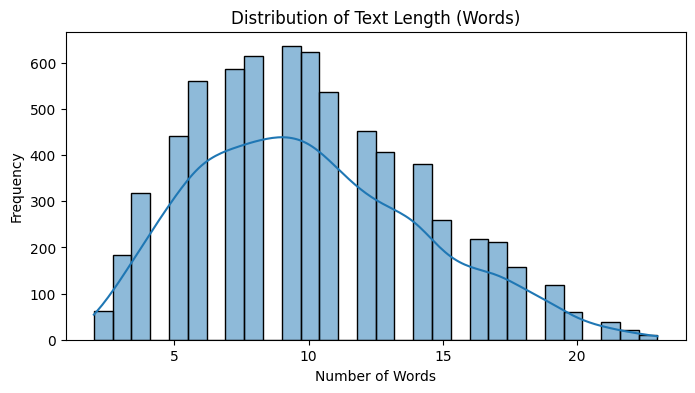

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Label Distribution
plt.figure(figsize=(6,4))
sns.countplot(data=df, x="label")
plt.title("Class Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

# Text Length After Cleaning
df["clean_length"] = df["clean_text"].apply(lambda x: len(str(x).split()))

plt.figure(figsize=(8,4))
sns.histplot(df["clean_length"], bins=30, kde=True)
plt.title("Distribution of Text Length (Words)")
plt.xlabel("Number of Words")
plt.ylabel("Frequency")
plt.show()

The dataset is imbalanced, with more real samples than fake samples. Most texts are short and tweet-like, averaging around 9–10 words.

# 6. TF-IDF Feature Extraction

# 7. PCA Visualization

TF-IDF Shape: (6903, 3000)


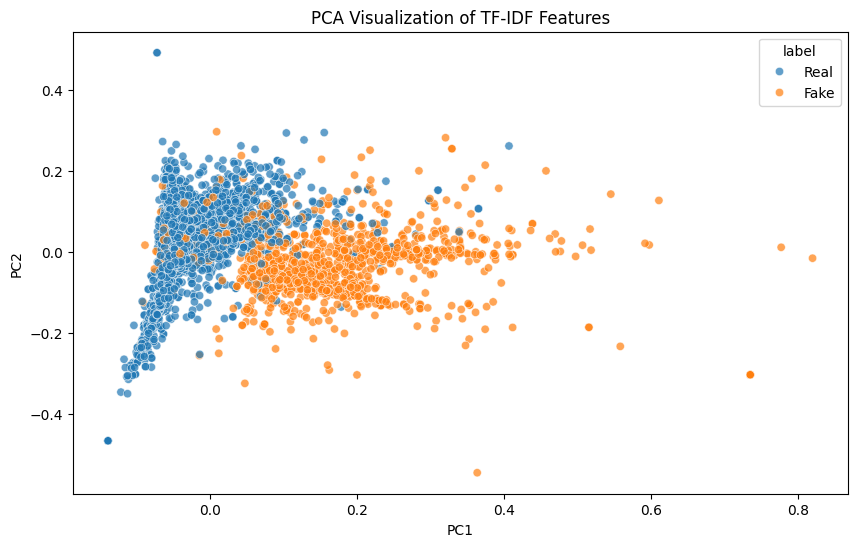

In [14]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns

# TF-IDF
tfidf = TfidfVectorizer(max_features=3000, ngram_range=(1,2))
X_tfidf = tfidf.fit_transform(df["clean_text"])

print("TF-IDF Shape:", X_tfidf.shape)

# PCA reduce to 2D
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_tfidf.toarray())

# Plot
plt.figure(figsize=(10,6))
sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=df["label"],
    alpha=0.7
)

plt.title("PCA Visualization of TF-IDF Features")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()

# 8. t-SNE Visualization

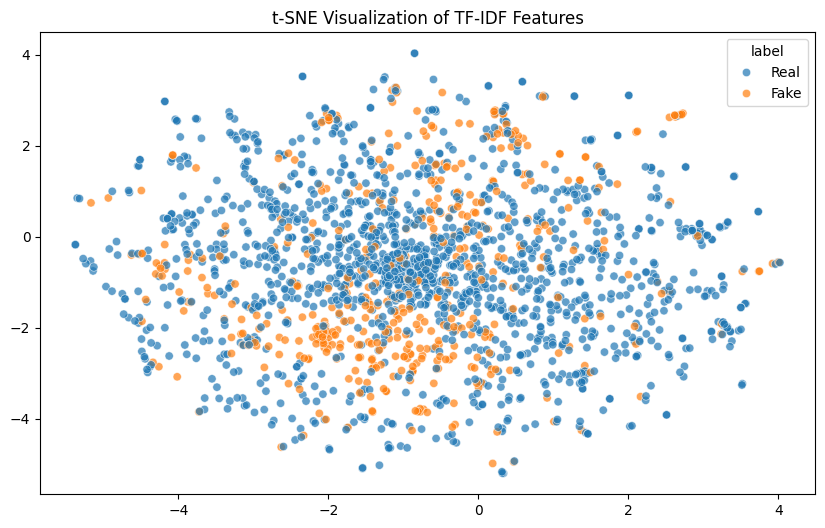

In [15]:
from sklearn.manifold import TSNE

sample_df = df.sample(2000, random_state=42)

X_sample = tfidf.transform(sample_df["clean_text"]).toarray()

tsne = TSNE(n_components=2, random_state=42, perplexity=30)
X_tsne = tsne.fit_transform(X_sample)

plt.figure(figsize=(10,6))
sns.scatterplot(
    x=X_tsne[:,0],
    y=X_tsne[:,1],
    hue=sample_df["label"],
    alpha=0.7
)

plt.title("t-SNE Visualization of TF-IDF Features")
plt.show()

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# Encode labels
le = LabelEncoder()
df["target"] = le.fit_transform(df["label"])  
# Fake=0 / Real=1 (or reverse depending on encoding)

print(dict(zip(le.classes_, le.transform(le.classes_))))

# Split
X_train, X_test, y_train, y_test = train_test_split(
    df["clean_text"],
    df["target"],
    test_size=0.2,
    random_state=42,
    stratify=df["target"]
)

print("Train Size:", len(X_train))
print("Test Size:", len(X_test))

{'Fake': np.int64(0), 'Real': np.int64(1)}
Train Size: 5522
Test Size: 1381


# 11. Model 1 — XGBoost + TF-IDF

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import xgboost as xgb

# TF-IDF
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))

X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)

# XGBoost model
xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric="logloss",
    random_state=42
)

xgb_model.fit(X_train_tfidf, y_train)

# Predictions
y_pred_xgb = xgb_model.predict(X_test_tfidf)

# Results
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb, target_names=le.classes_))

Accuracy: 0.9123823316437364
              precision    recall  f1-score   support

        Fake       0.87      0.73      0.80       323
        Real       0.92      0.97      0.94      1058

    accuracy                           0.91      1381
   macro avg       0.90      0.85      0.87      1381
weighted avg       0.91      0.91      0.91      1381



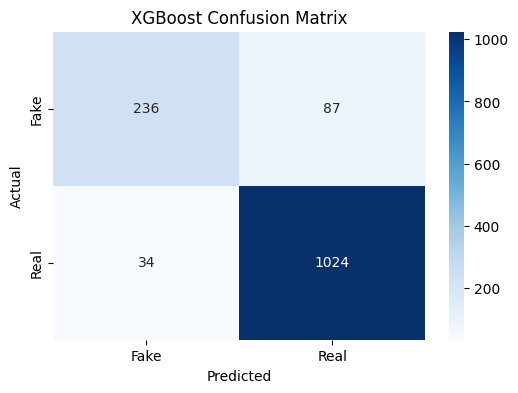

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_xgb)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_,
            yticklabels=le.classes_)

plt.title("XGBoost Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [19]:
!pip install transformers datasets accelerate -q

In [23]:
train_df = pd.DataFrame({
    "text": X_train.values,
    "label": y_train
})

test_df = pd.DataFrame({
    "text": X_test.values,
    "label": y_test
})

train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

In [24]:
model_name = "aubmindlab/bert-base-arabertv02"

tokenizer = AutoTokenizer.from_pretrained(model_name)

config.json:   0%|          | 0.00/384 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/381 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

In [25]:
def tokenize(batch):
    return tokenizer(
        batch["text"],
        padding="max_length",
        truncation=True,
        max_length=64
    )

train_dataset = train_dataset.map(tokenize, batched=True)
test_dataset = test_dataset.map(tokenize, batched=True)

train_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])
test_dataset.set_format("torch", columns=["input_ids", "attention_mask", "label"])

Map:   0%|          | 0/5522 [00:00<?, ? examples/s]

Map:   0%|          | 0/1381 [00:00<?, ? examples/s]

In [26]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=2
)

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: aubmindlab/bert-base-arabertv02
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.embeddings.position_ids               | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Conside

In [27]:
def compute_metrics(pred):
    labels = pred.label_ids
    preds = pred.predictions.argmax(-1)

    precision, recall, f1, _ = precision_recall_fscore_support(
        labels, preds, average="weighted"
    )

    acc = accuracy_score(labels, preds)

    return {
        "accuracy": acc,
        "precision": precision,
        "recall": recall,
        "f1": f1
    }

In [28]:
training_args = TrainingArguments(
    output_dir="./results",
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_dir="./logs",
    learning_rate=2e-5,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    report_to="none"
)

`logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


In [29]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

In [30]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1
1,No log,0.638690,0.884866,0.882024,0.884866,0.878180
2,No log,0.626574,0.876901,0.879223,0.876901,0.877919
3,0.527137,0.569089,0.900072,0.898060,0.900072,0.898705


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['bert.embeddings.LayerNorm.weight', 'bert.embeddings.LayerNorm.bias', 'bert.encoder.layer.0.attention.output.LayerNorm.weight', 'bert.encoder.layer.0.attention.output.LayerNorm.bias', 'bert.encoder.layer.0.output.LayerNorm.weight', 'bert.encoder.layer.0.output.LayerNorm.bias', 'bert.encoder.layer.1.attention.output.LayerNorm.weight', 'bert.encoder.layer.1.attention.output.LayerNorm.bias', 'bert.encoder.layer.1.output.LayerNorm.weight', 'bert.encoder.layer.1.output.LayerNorm.bias', 'bert.encoder.layer.2.attention.output.LayerNorm.weight', 'bert.encoder.layer.2.attention.output.LayerNorm.bias', 'bert.encoder.layer.2.output.LayerNorm.weight', 'bert.encoder.layer.2.output.LayerNorm.bias', 'bert.encoder.layer.3.attention.output.LayerNorm.weight', 'bert.encoder.layer.3.attention.output.LayerNorm.bias', 'bert.encoder.layer.3.output.LayerNorm.weight', 'bert.encoder.layer.3.output.LayerNorm.bias', 'bert.encoder.layer.4.attention.output.La

TrainOutput(global_step=519, training_loss=0.5178243107878404, metrics={'train_runtime': 174.7934, 'train_samples_per_second': 94.775, 'train_steps_per_second': 2.969, 'total_flos': 544837217886720.0, 'train_loss': 0.5178243107878404, 'epoch': 3.0})

In [31]:
results = trainer.evaluate()
print(results)

/usr/local/lib/python3.12/dist-packages/torch/autograd/function.py:583: UserWarning: Was asked to gather along dimension 0, but all input tensors were scalars; will instead unsqueeze and return a vector.
  return super().apply(*args, **kwargs)  # type: ignore[misc]


{'eval_loss': 0.5690891742706299, 'eval_accuracy': 0.9000724112961622, 'eval_precision': 0.8980604069456739, 'eval_recall': 0.9000724112961622, 'eval_f1': 0.8987048894673998, 'eval_runtime': 4.2616, 'eval_samples_per_second': 324.056, 'eval_steps_per_second': 10.325, 'epoch': 3.0}


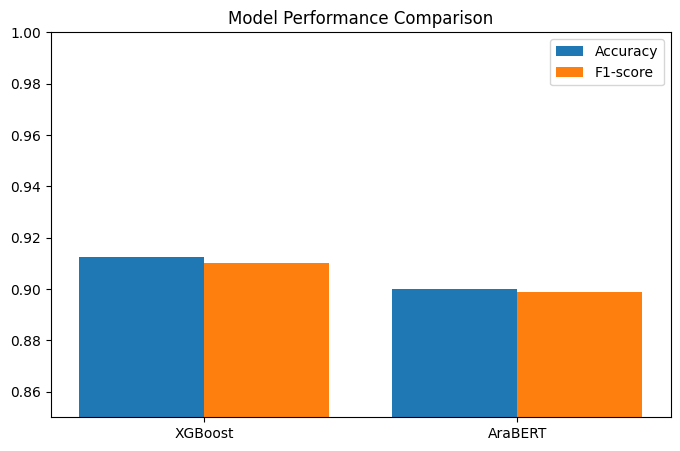

In [32]:
import matplotlib.pyplot as plt

models = ["XGBoost", "AraBERT"]
accuracy = [0.9124, 0.9001]
f1 = [0.91, 0.8987]

x = range(len(models))

plt.figure(figsize=(8,5))
plt.bar(x, accuracy, width=0.4, label="Accuracy")
plt.bar([i + 0.4 for i in x], f1, width=0.4, label="F1-score")

plt.xticks([i + 0.2 for i in x], models)
plt.ylim(0.85,1.0)
plt.title("Model Performance Comparison")
plt.legend()
plt.show()

In [33]:
df2 = pd.read_excel("/kaggle/input/datasets/abdelrahmanelkassem/2-5-million-dataset/6.Political Tweets.xlsx")
print(df2.columns)
df2.head()

Index(['Text', 'Year', 'Source'], dtype='object')


,Text,Year,Source
0,غني الحريه دي أجمل غنوه في الوجوه شمس الح...,2019,Arabic Political Tweets
1,شامم ريحة أحداث يناير,2019,Arabic Political Tweets
2,اكتر من ربع مليون تغريدة ليه ابو لهب هو ولا...,2019,Arabic Political Tweets
3,لا لإهانة اولادنا بيد العرص,2019,Arabic Political Tweets
4,هذا هو حال المصريين في عهد البسطويسي وعصاب...,2019,Arabic Political Tweets


# 12. Model 2 — BiLSTM + Custom Word2Vec

In [37]:
import pandas as pd
import os

files = [
    "/kaggle/input/datasets/abdelrahmanelkassem/2-5-million-dataset/10.SADID.xlsx",
    "/kaggle/input/datasets/abdelrahmanelkassem/2-5-million-dataset/11.DART.xlsx",
    "/kaggle/input/datasets/abdelrahmanelkassem/2-5-million-dataset/12.Callhome.xlsx",
    "/kaggle/input/datasets/abdelrahmanelkassem/2-5-million-dataset/2.Egyptian Tweets.xlsx",
    "/kaggle/input/datasets/abdelrahmanelkassem/2-5-million-dataset/3.TaghreedT.xlsx",
    "/kaggle/input/datasets/abdelrahmanelkassem/2-5-million-dataset/5.Habibi.xlsx",
    "/kaggle/input/datasets/abdelrahmanelkassem/2-5-million-dataset/6.Political Tweets.xlsx",
    "/kaggle/input/datasets/abdelrahmanelkassem/2-5-million-dataset/7.Reddit.xlsx",
    "/kaggle/input/datasets/abdelrahmanelkassem/2-5-million-dataset/8.Arabic_Egyptian_Wikipedia.xlsx",
    "/kaggle/input/datasets/abdelrahmanelkassem/2-5-million-dataset/9.QCRI.xlsx"
]

all_texts = []

for file in files:
    temp = pd.read_excel(file)
    
    if "Text" in temp.columns:
        texts = temp["Text"].dropna().astype(str).tolist()
        all_texts.extend(texts)

print("Total External Text Samples:", len(all_texts))
print("Sample:")
print(all_texts[:5])

Total External Text Samples: 519640
Sample:
['مش معقول! متوقعتش إني أشوفك هنا', 'معلش كنت بجيب حاجة', 'هي مراتك بعتاك تتجسس عليا؟', 'إيه؟ لا هو إنت خايف من حاجة ولا إيه؟', 'إنت مش بس دعيت واحدة حامل لبيتك وسيبها. أنا ممكن أكون حرامية. عشان تكون عارف.']


In [38]:
!pip install gensim -q

In [39]:
from gensim.utils import simple_preprocess
from gensim.models import Word2Vec

# Tokenize texts
sentences = []

for text in all_texts:
    tokens = simple_preprocess(str(text), deacc=False)
    if len(tokens) > 2:
        sentences.append(tokens)

print("Total Sentences:", len(sentences))
print("Sample Tokens:", sentences[0][:10])

# Train Word2Vec
w2v_model = Word2Vec(
    sentences=sentences,
    vector_size=100,
    window=5,
    min_count=3,
    workers=4,
    sg=1
)

print("Vocabulary Size:", len(w2v_model.wv))

Total Sentences: 494954
Sample Tokens: ['مش', 'معقول', 'متوقعتش', 'إني', 'أشوفك', 'هنا']
Vocabulary Size: 93725


In [40]:
!pip install tensorflow -q

In [41]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

MAX_WORDS = 30000
MAX_LEN = 25

tokenizer = Tokenizer(num_words=MAX_WORDS, oov_token="<OOV>")
tokenizer.fit_on_texts(df["clean_text"])

X_seq = tokenizer.texts_to_sequences(df["clean_text"])
X_pad = pad_sequences(X_seq, maxlen=MAX_LEN, padding="post")

y = df["target"].values

print("Shape:", X_pad.shape)

2026-04-18 21:48:08.948146: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776548889.163422      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776548889.227130      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1776548889.758220      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776548889.758266      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1776548889.758269      55 computation_placer.cc:177] computation placer alr

Shape: (6903, 25)


In [42]:
import numpy as np

EMBED_DIM = 100
word_index = tokenizer.word_index

num_words = min(MAX_WORDS, len(word_index) + 1)

embedding_matrix = np.zeros((num_words, EMBED_DIM))

for word, i in word_index.items():
    if i >= MAX_WORDS:
        continue
        
    if word in w2v_model.wv:
        embedding_matrix[i] = w2v_model.wv[word]

print("Embedding Matrix Shape:", embedding_matrix.shape)

Embedding Matrix Shape: (17190, 100)


In [43]:
from sklearn.model_selection import train_test_split
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Bidirectional, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.metrics import Precision, Recall

# Split
X_train_dl, X_test_dl, y_train_dl, y_test_dl = train_test_split(
    X_pad, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Model
model = Sequential([
    Embedding(
        input_dim=num_words,
        output_dim=EMBED_DIM,
        weights=[embedding_matrix],
        input_length=MAX_LEN,
        trainable=False
    ),
    
    Bidirectional(LSTM(64, return_sequences=False)),
    Dropout(0.5),
    
    Dense(32, activation="relu"),
    Dropout(0.3),
    
    Dense(1, activation="sigmoid")
])

model.compile(
    loss="binary_crossentropy",
    optimizer="adam",
    metrics=["accuracy", Precision(), Recall()]
)

model.summary()

# Train
history = model.fit(
    X_train_dl,
    y_train_dl,
    validation_split=0.1,
    epochs=10,
    batch_size=32,
    callbacks=[EarlyStopping(patience=2, restore_best_weights=True)],
    verbose=1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:97: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(
I0000 00:00:1776548981.534902      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 10809 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1776548981.540249      55 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 12255 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │     1,719,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,719,000 (6.56 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 1,719,000 (6.56 MB)

Epoch 1/10


I0000 00:00:1776548986.899626    2241 cuda_dnn.cc:529] Loaded cuDNN version 91002


156/156 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - accuracy: 0.7934 - loss: 0.4960 - precision: 0.8019 - recall: 0.9731 - val_accuracy: 0.9150 - val_loss: 0.2584 - val_precision: 0.9146 - val_recall: 0.9784
Epoch 2/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9074 - loss: 0.2807 - precision: 0.9019 - recall: 0.9845 - val_accuracy: 0.9277 - val_loss: 0.2172 - val_precision: 0.9253 - val_recall: 0.9832
Epoch 3/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9161 - loss: 0.2494 - precision: 0.9176 - recall: 0.9787 - val_accuracy: 0.9114 - val_loss: 0.2450 - val_precision: 0.8963 - val_recall: 0.9976
Epoch 4/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - accuracy: 0.9177 - loss: 0.2439 - precision: 0.9127 - recall: 0.9860 - val_accuracy: 0.9259 - val_loss: 0.1975 - val_precision: 0.9195 - val_recall: 0.9880
Epoch 5/10
156/156 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.9213 - loss: 0.2287 - precision: 0.9197 - recall: 0.9828 - val_accuracy: 0.9204 - val_loss: 0.2172 - 

In [44]:
loss, acc, prec, rec = model.evaluate(X_test_dl, y_test_dl, verbose=0)

print("Test Accuracy:", acc)
print("Precision:", prec)
print("Recall:", rec)

Test Accuracy: 0.9022447466850281
Precision: 0.9030567407608032
Recall: 0.9773156642913818


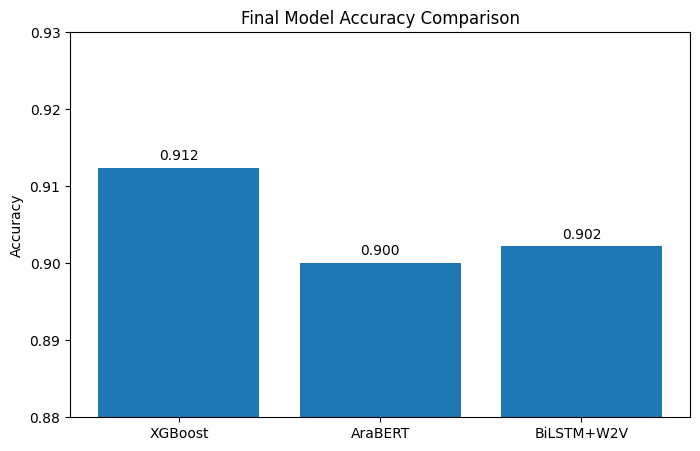

In [45]:
import matplotlib.pyplot as plt

models = ["XGBoost", "AraBERT", "BiLSTM+W2V"]
accuracy = [0.9124, 0.9001, 0.9022]

plt.figure(figsize=(8,5))
bars = plt.bar(models, accuracy)

plt.ylim(0.88,0.93)
plt.title("Final Model Accuracy Comparison")
plt.ylabel("Accuracy")

for bar in bars:
    y = bar.get_height()
    plt.text(bar.get_x()+bar.get_width()/2, y+0.001, f"{y:.3f}", ha='center')

plt.show()